In [7]:
# import
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [ ]:
# fetch data
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
X_Scaled = StandardScaler().fit_transform(X)

Text(0, 0.5, 'WCSS')

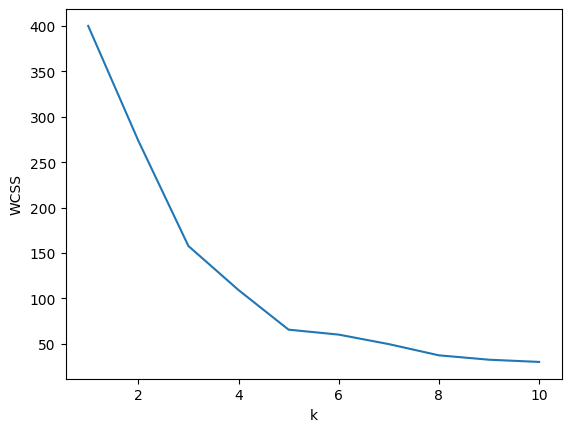

In [14]:
# ELBOW METHOD

wcss = [] # "within cluster sum of squares"

for k in range(1, 11):
    k_means = KMeans(n_clusters = k, init = "k-means++", random_state = 42)
    k_means.fit(X_Scaled)
    wcss.append(k_means.inertia_)

# plot elbow method
plt.plot(range(1, 11), wcss)
plt.xlabel("k")
plt.ylabel("WCSS")



# ELBOW METHOD ANALYSIS
Based off the elbow method, I see that the drop in WCSS suddenly starts to become smaller at K=3, so that's what I will be going with moving forward.

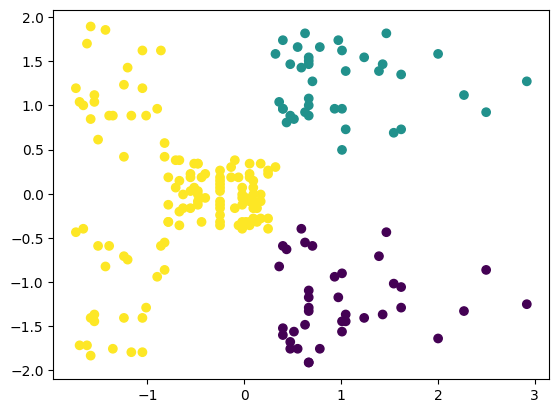

In [16]:

k = 3 # num clusters


k_means = KMeans(n_clusters = k, init = "k-means++", random_state = 42)
k_means.fit(X_Scaled)

labels = k_means.labels_


plt.scatter(X_Scaled[:,0], X_Scaled[:,1], c=labels, cmap='viridis')

